In [1]:
from pathlib import Path 
import pandas as pd
import numpy as np

data_dir = Path("../data")

df = pd.read_csv(data_dir/'merged.csv')

df.head()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,1381629,443,5577389,5,1,123,46,46,0,24.600000,...,32,37015.0,0.0000,37015,37015,5527113.0,0.000,5527113,5527113,BENIGN
1,2596419,53469,30,1,1,6,6,6,6,6.000000,...,20,0.0,0.0000,0,0,0.0,0.000,0,0,BENIGN
2,1499785,53,888,2,2,62,246,31,31,31.000000,...,32,0.0,0.0000,0,0,0.0,0.000,0,0,BENIGN
3,1525889,53022,198,3,1,31,6,31,0,10.333333,...,32,0.0,0.0000,0,0,0.0,0.000,0,0,BENIGN
4,579567,443,116657713,24,25,1318,20487,579,0,54.916667,...,32,330945.5,415998.6975,625101,36790,58000000.0,1250244.692,58800000,57100000,BENIGN


In [2]:
df = df.drop('Unnamed: 0', axis = 1)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             45000 non-null  int64  
 1   Flow Duration                45000 non-null  int64  
 2   Total Fwd Packets            45000 non-null  int64  
 3   Total Backward Packets       45000 non-null  int64  
 4   Total Length of Fwd Packets  45000 non-null  int64  
 5   Total Length of Bwd Packets  45000 non-null  int64  
 6   Fwd Packet Length Max        45000 non-null  int64  
 7   Fwd Packet Length Min        45000 non-null  int64  
 8   Fwd Packet Length Mean       45000 non-null  float64
 9   Fwd Packet Length Std        45000 non-null  float64
 10  Bwd Packet Length Max        45000 non-null  int64  
 11  Bwd Packet Length Min        45000 non-null  int64  
 12  Bwd Packet Length Mean       45000 non-null  float64
 13  Bwd Packet Lengt

In [4]:
df['Flow Bytes/s'] = df['Flow Bytes/s'].replace([np.inf, -np.inf], np.nan)
df['Flow Bytes/s'] = df['Flow Bytes/s'].fillna(df['Flow Bytes/s'].median())

df['Flow Bytes/s'].isna().sum()

np.int64(0)

In [5]:
import numpy as np

print("Infinite values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sort_values(ascending=False).head(10))

Infinite values:
Flow Packets/s                 36
Destination Port                0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Flow Duration                   0
Fwd Packet Length Max           0
Fwd Packet Length Min           0
Fwd Packet Length Mean          0
Fwd Packet Length Std           0
dtype: int64


In [6]:
df['Flow Packets/s'] = df['Flow Packets/s'].replace([np.inf, -np.inf], np.nan)
df['Flow Packets/s'] = df['Flow Packets/s'].fillna(df['Flow Packets/s'].median())

df['Flow Packets/s'].isna().sum()

np.int64(0)

In [7]:
unique_counts = df.nunique()
print(unique_counts.sort_values().head(15))

Bwd PSH Flags           1
Fwd Avg Bulk Rate       1
Bwd Avg Bytes/Bulk      1
Bwd Avg Packets/Bulk    1
Fwd Avg Packets/Bulk    1
Fwd Avg Bytes/Bulk      1
Bwd Avg Bulk Rate       1
Bwd URG Flags           1
Fwd URG Flags           2
Fwd PSH Flags           2
RST Flag Count          2
SYN Flag Count          2
ACK Flag Count          2
PSH Flag Count          2
URG Flag Count          2
dtype: int64


In [8]:
constant_cols = unique_counts[unique_counts == 1].index
print(constant_cols.tolist())

['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [9]:
constant_cols = unique_counts[unique_counts == 1].index
df = df.drop(columns=constant_cols)
print(df.shape)

(45000, 71)


In [10]:
print(df['Fwd Header Length'].equals(df['Fwd Header Length.1']))

True


In [11]:
df = df.drop('Fwd Header Length.1', axis = 1)

In [12]:
df.shape

(45000, 70)

In [13]:
df.duplicated().sum()

np.int64(5180)

In [14]:
df = df.drop_duplicates()
df.shape

(39820, 70)

In [15]:
corr = df.drop(columns=['Label']).corr()

high_corr = (
    corr.abs()
    .where(~np.eye(corr.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print(high_corr.head(20))

Subflow Bwd Bytes            Total Length of Bwd Packets    1.00000
Total Fwd Packets            Subflow Fwd Packets            1.00000
Fwd Packet Length Mean       Avg Fwd Segment Size           1.00000
Fwd URG Flags                CWE Flag Count                 1.00000
CWE Flag Count               Fwd URG Flags                  1.00000
ECE Flag Count               RST Flag Count                 1.00000
Total Length of Fwd Packets  Subflow Fwd Bytes              1.00000
Avg Bwd Segment Size         Bwd Packet Length Mean         1.00000
SYN Flag Count               Fwd PSH Flags                  1.00000
Fwd PSH Flags                SYN Flag Count                 1.00000
Avg Fwd Segment Size         Fwd Packet Length Mean         1.00000
Bwd Packet Length Mean       Avg Bwd Segment Size           1.00000
RST Flag Count               ECE Flag Count                 1.00000
Total Length of Bwd Packets  Subflow Bwd Bytes              1.00000
Total Backward Packets       Subflow Bwd Packets

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

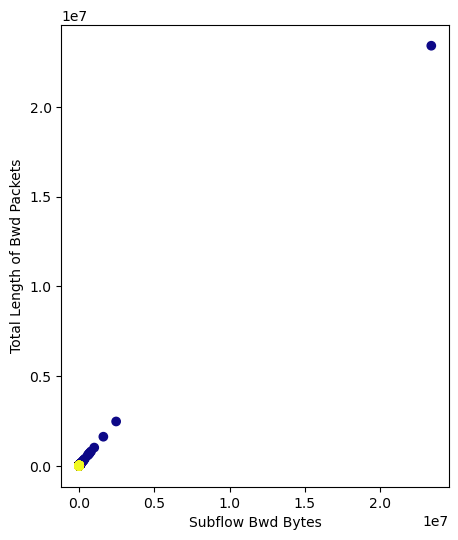

In [17]:
fig = plt.figure(figsize = (5, 6))
labels, categories = pd.factorize(df['Label'])

plt.scatter( df['Subflow Bwd Bytes'], df['Total Length of Bwd Packets'], c = labels, cmap = 'plasma')
plt.xlabel("Subflow Bwd Bytes")
plt.ylabel("Total Length of Bwd Packets")
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x17a5fbb7c50>,
 'caps': [<matplotlib.lines.Line2D at 0x17a60457610>,
 'boxes': [<matplotlib.lines.Line2D at 0x17a5fbb7b10>],
 'medians': [<matplotlib.lines.Line2D at 0x17a60456710>],
 'fliers': [<matplotlib.lines.Line2D at 0x17a60456850>],
 'means': []}

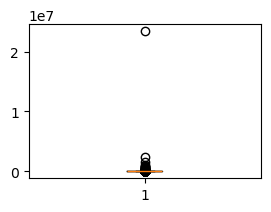

In [18]:
fig = plt.figure(figsize = (3, 2))
plt.boxplot(df['Subflow Bwd Bytes'])

In [19]:
Q1 = df['Flow Duration'].quantile(0.25)
Q3 = df['Flow Duration'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Flow Duration'] < lower) | (df['Flow Duration'] > upper)]
print(len(outliers))

0


{'whiskers': [<matplotlib.lines.Line2D at 0x17a604b2c10>,
 'caps': [<matplotlib.lines.Line2D at 0x17a604b2e90>,
 'boxes': [<matplotlib.lines.Line2D at 0x17a604b2ad0>],
 'medians': [<matplotlib.lines.Line2D at 0x17a604b3110>],
 'fliers': [<matplotlib.lines.Line2D at 0x17a604b3250>],
 'means': []}

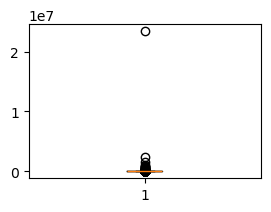

In [20]:
fig = plt.figure(figsize = (3, 2))
plt.boxplot(df['Total Length of Bwd Packets'])

In [21]:
Q1 = df['Total Length of Bwd Packets'].quantile(0.25)
Q3 = df['Total Length of Bwd Packets'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Total Length of Bwd Packets'] < lower) | (df['Total Length of Bwd Packets'] > upper)]
print(len(outliers))

9250


In [22]:
features = df.drop(columns=['Label']).select_dtypes(include=np.number).columns
print(len(features))

69


In [23]:
print("outliers may be")
for colname in features:
    q1 = df[colname].quantile(0.25)
    q3 = df[colname].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5*IQR
    upper = q3 + 1.5*IQR

    outlier = df[ (df[colname] < lower) | (df[colname] > upper) ]
    print(f"{colname} --> {len(outlier)} ///////////////", end = ' ')
    

outliers may be
Destination Port --> 15918 /////////////// Flow Duration --> 0 /////////////// Total Fwd Packets --> 2957 /////////////// Total Backward Packets --> 5463 /////////////// Total Length of Fwd Packets --> 5525 /////////////// Total Length of Bwd Packets --> 9250 /////////////// Fwd Packet Length Max --> 323 /////////////// Fwd Packet Length Min --> 8908 /////////////// Fwd Packet Length Mean --> 2984 /////////////// Fwd Packet Length Std --> 303 /////////////// Bwd Packet Length Max --> 2821 /////////////// Bwd Packet Length Min --> 7830 /////////////// Bwd Packet Length Mean --> 3920 /////////////// Bwd Packet Length Std --> 3885 /////////////// Flow Bytes/s --> 9287 /////////////// Flow Packets/s --> 9303 /////////////// Flow IAT Mean --> 2893 /////////////// Flow IAT Std --> 2727 /////////////// Flow IAT Max --> 5768 /////////////// Flow IAT Min --> 7245 /////////////// Fwd IAT Total --> 0 /////////////// Fwd IAT Mean --> 3009 /////////////// Fwd IAT Std --> 6745 //////

In [24]:
cols = [
    'Fwd URG Flags',
    'RST Flag Count',
    'CWE Flag Count',
    'ECE Flag Count',
    'min_seg_size_forward'
]

for col in cols:
    print("\n", col)
    print(df[df[col] > 0][['Label', col]])


 Fwd URG Flags
       Label  Fwd URG Flags
3791  BENIGN              1

 RST Flag Count
       Label  RST Flag Count
513   BENIGN               1
523   BENIGN               1
2197  BENIGN               1
3067  BENIGN               1

 CWE Flag Count
       Label  CWE Flag Count
3791  BENIGN               1

 ECE Flag Count
       Label  ECE Flag Count
513   BENIGN               1
523   BENIGN               1
2197  BENIGN               1
3067  BENIGN               1

 min_seg_size_forward
             Label  min_seg_size_forward
0           BENIGN                    32
1           BENIGN                    20
2           BENIGN                    32
3           BENIGN                    32
4           BENIGN                    32
...            ...                   ...
44992  SSH-Patator                    32
44995  SSH-Patator                    32
44996  SSH-Patator                    32
44997  SSH-Patator                    32
44999  SSH-Patator                    32

[39816 rows x

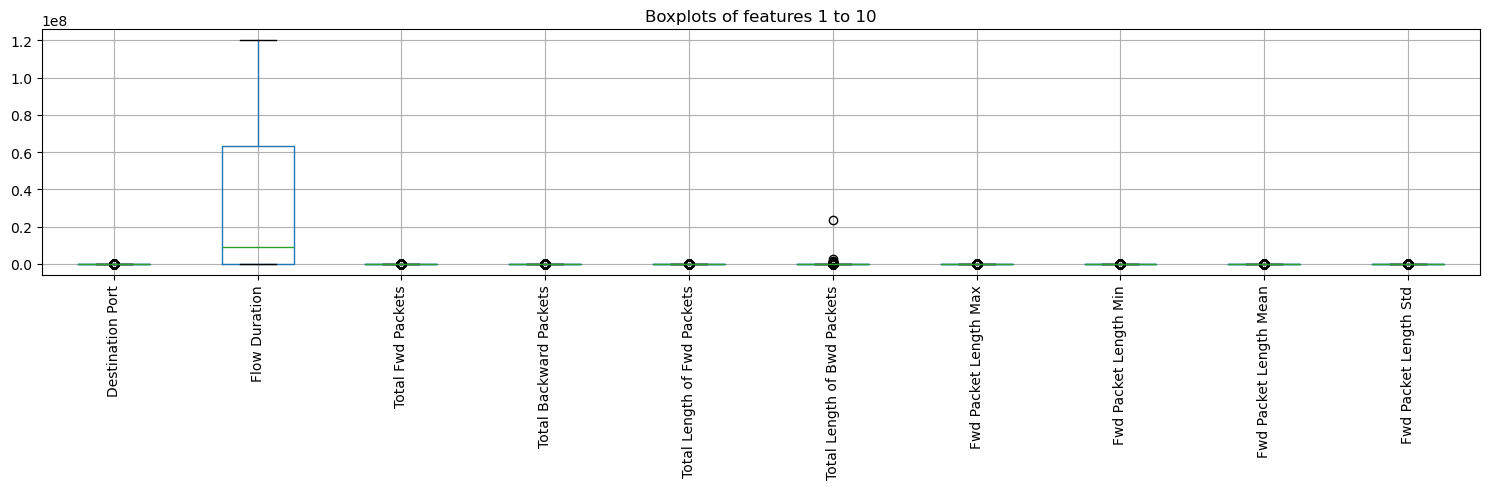

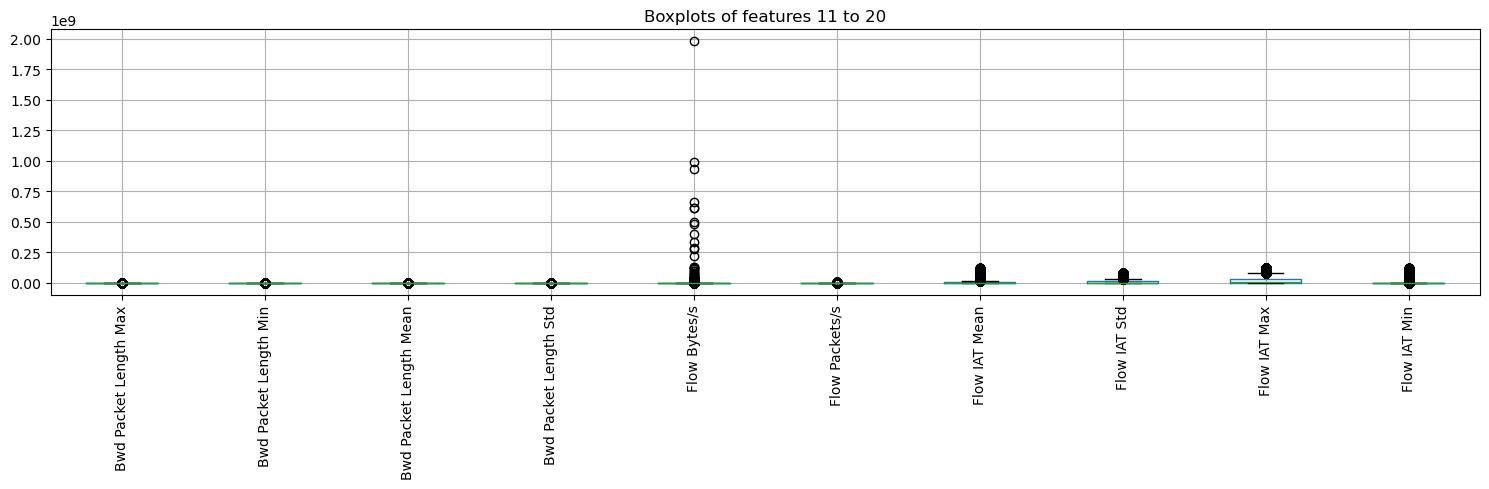

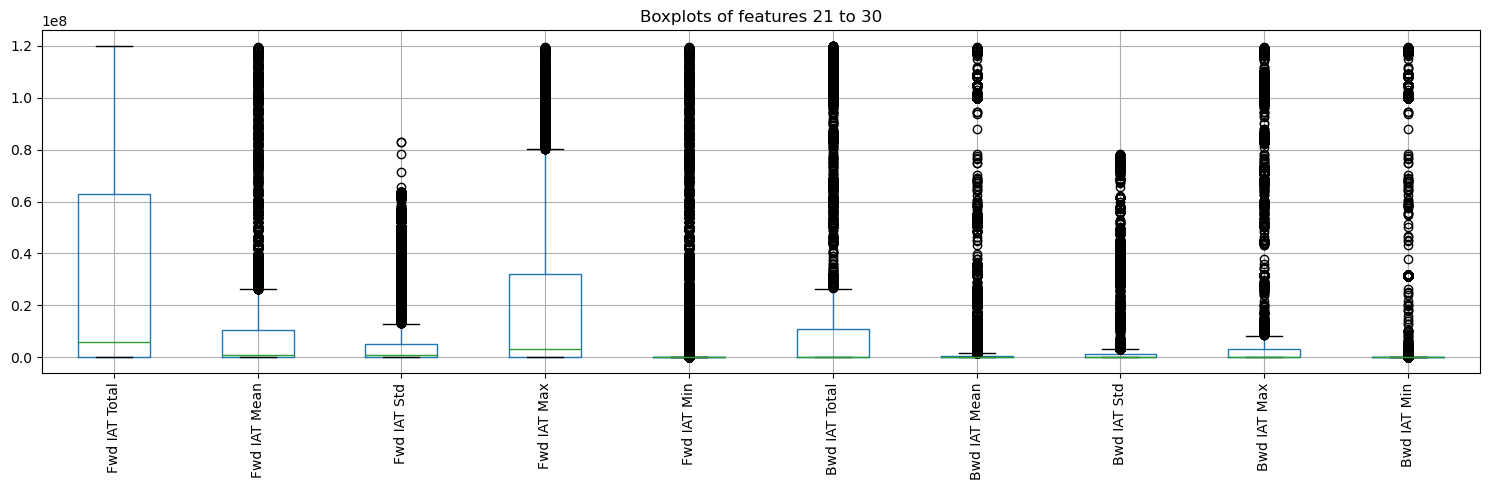

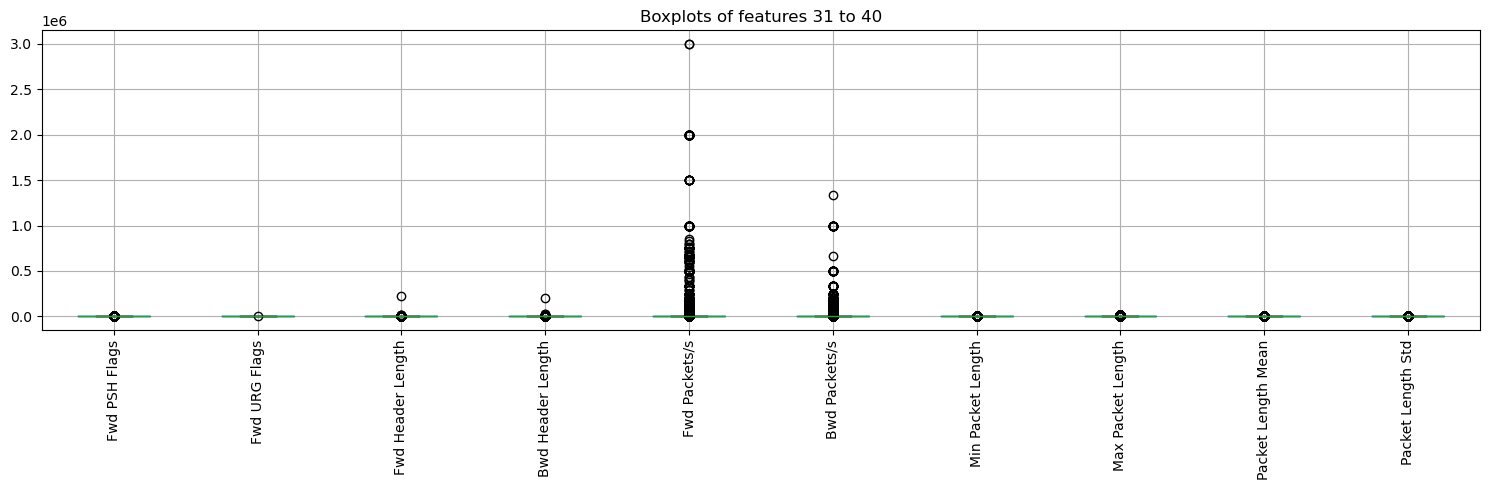

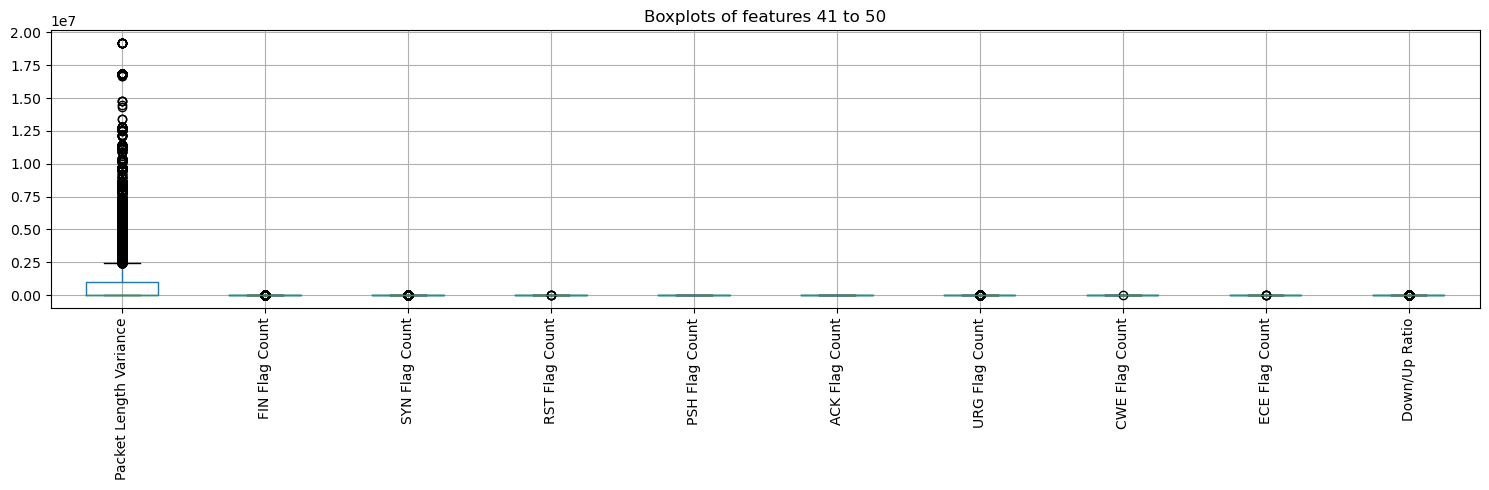

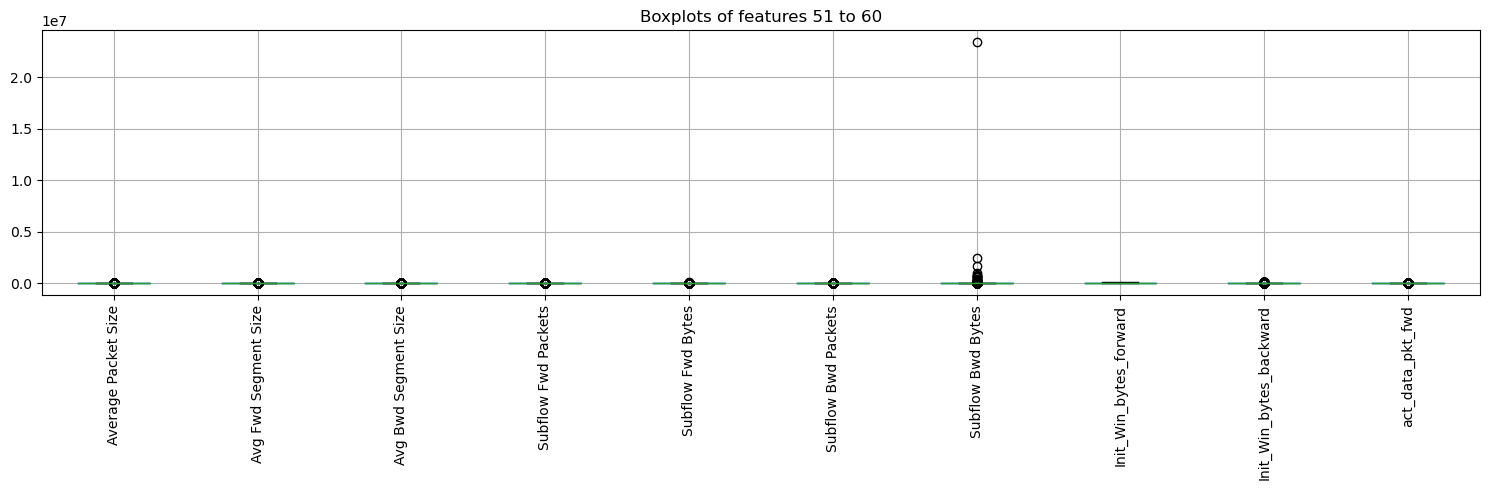

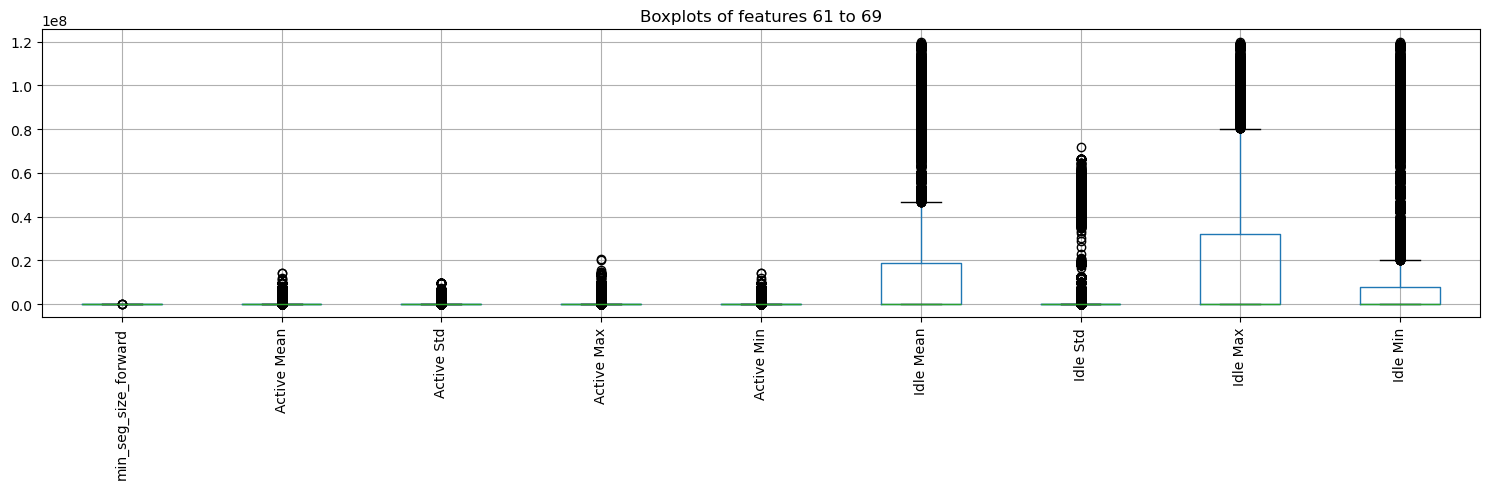

In [25]:
for i in range(0, len(features), 10):

    cols = features[i:i+10]

    plt.figure(figsize=(15, 5))

    df[cols].boxplot()

    plt.xticks(rotation=90)
    plt.title(f'Boxplots of features {i+1} to {i+len(cols)}')
    plt.tight_layout()
    plt.show()

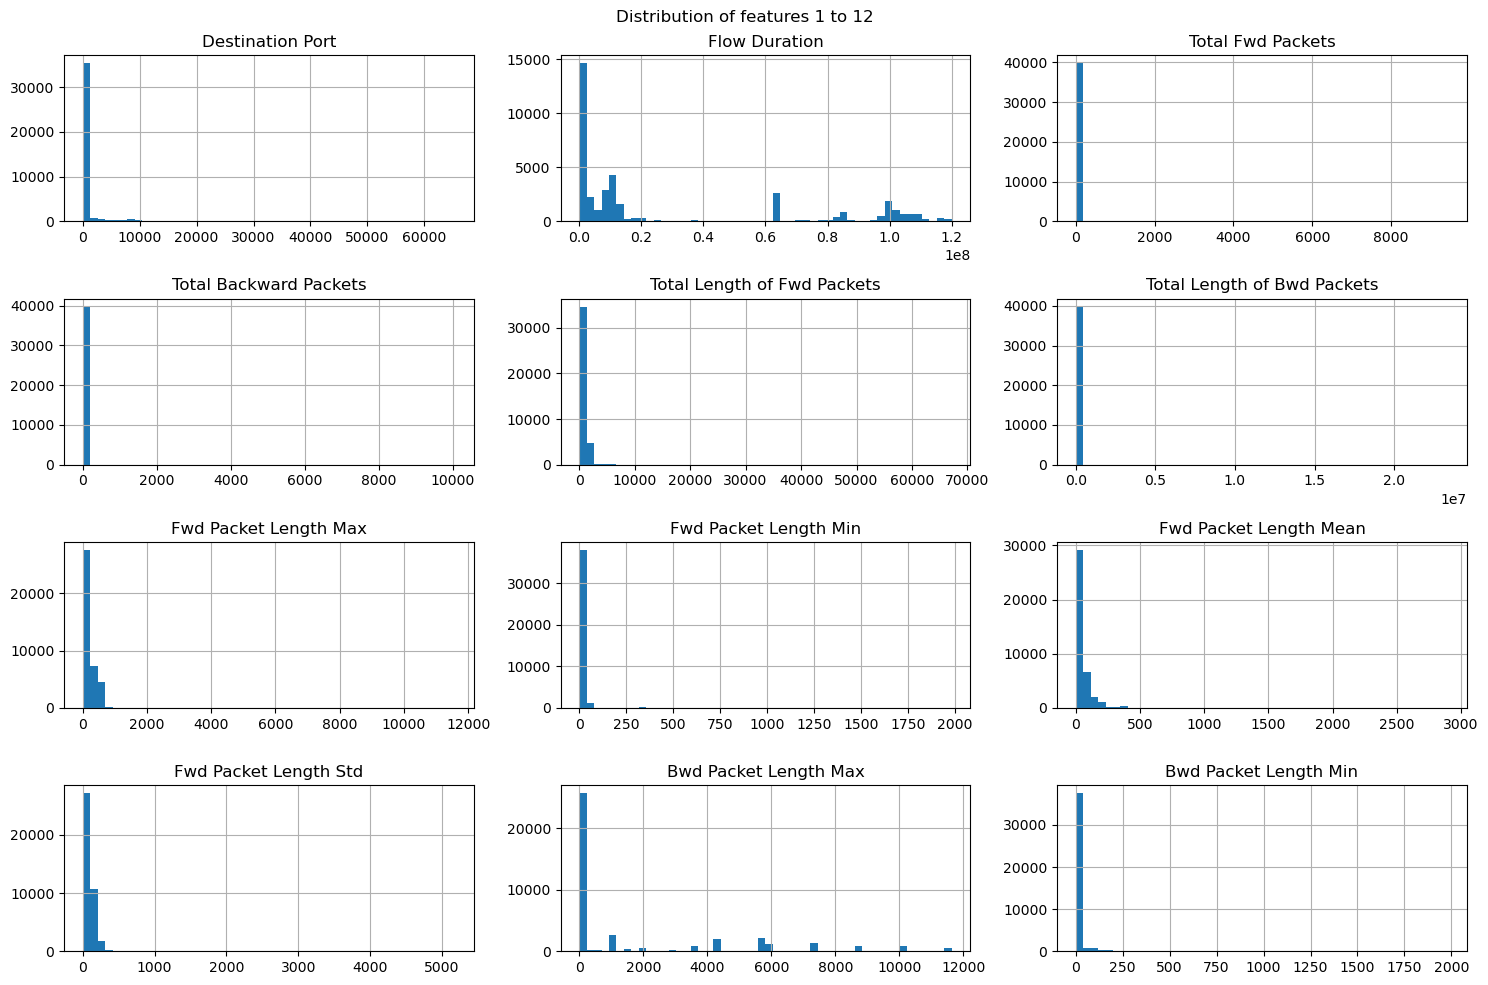

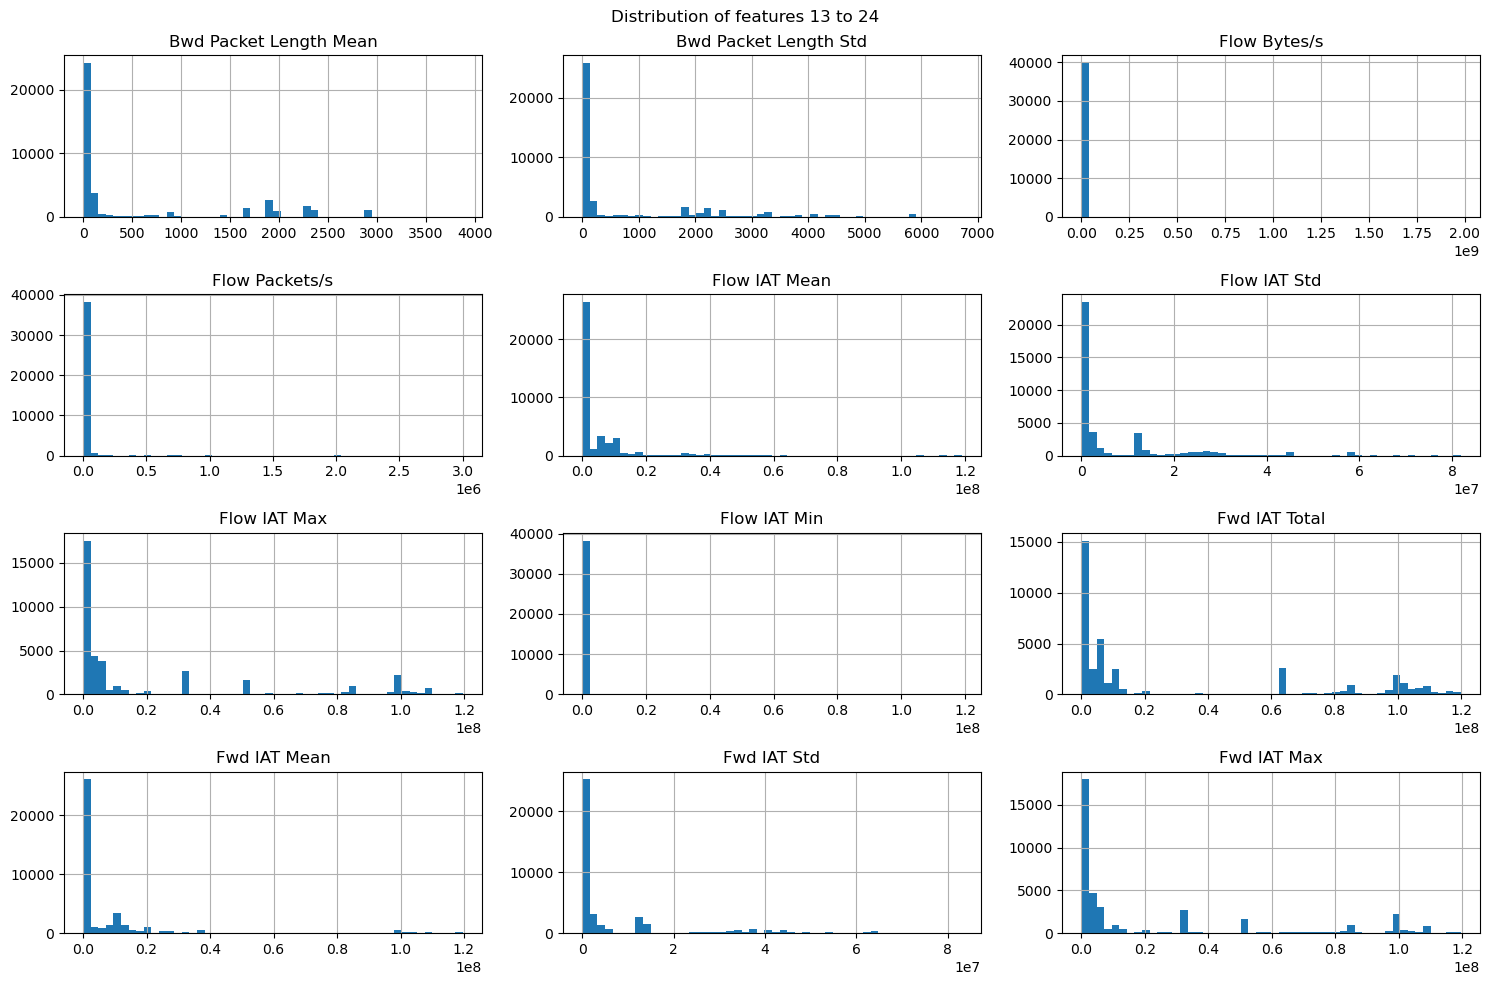

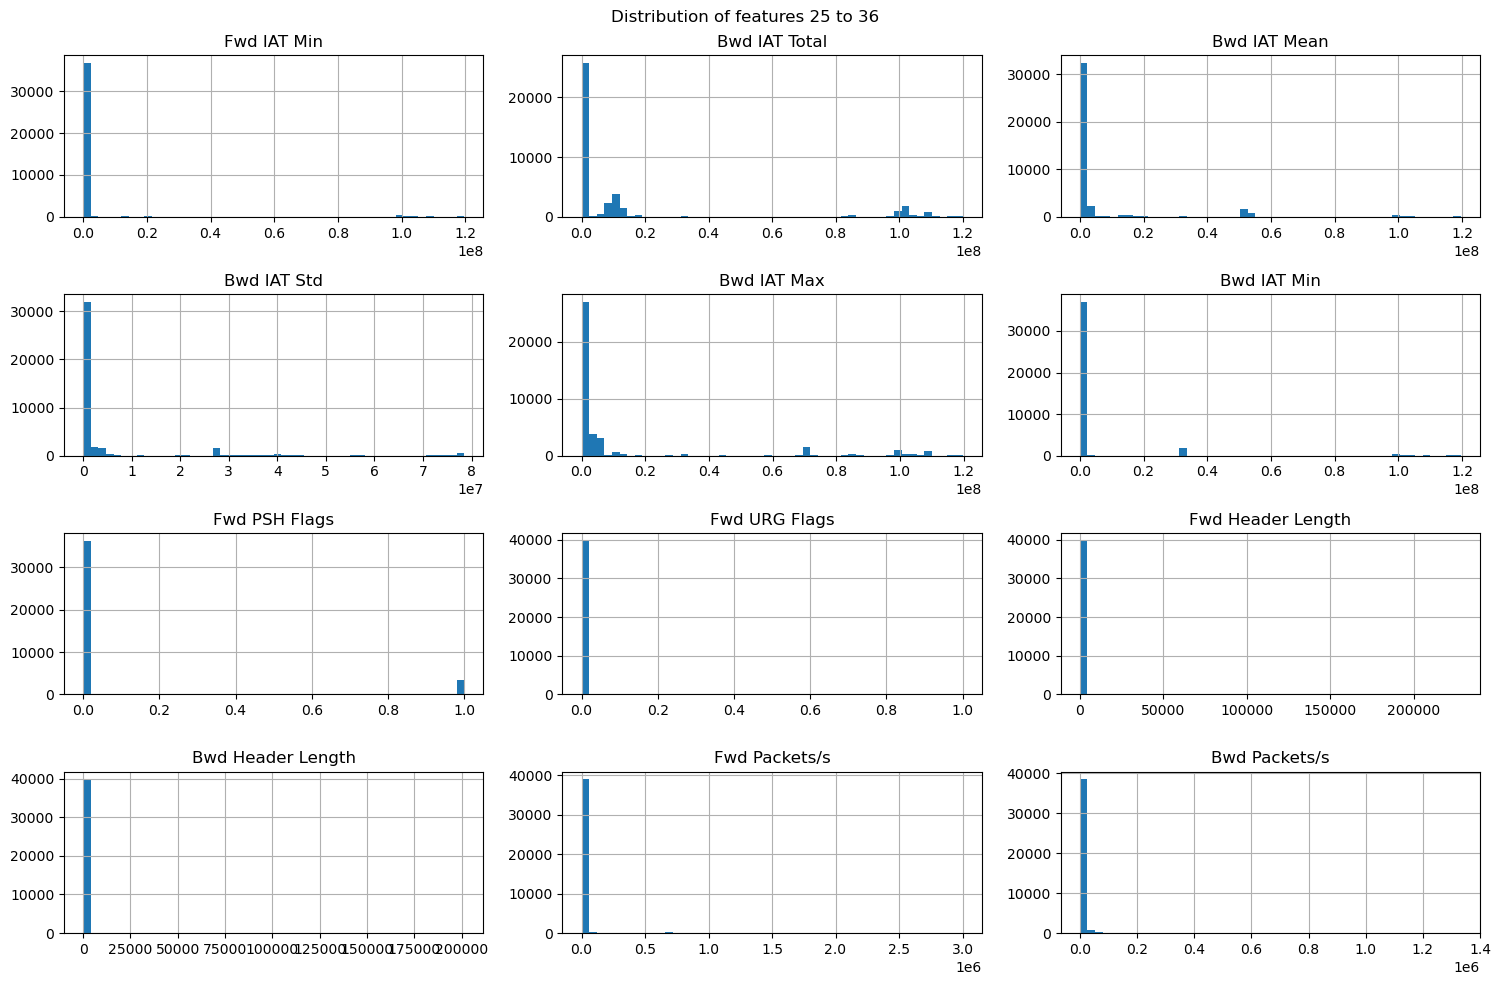

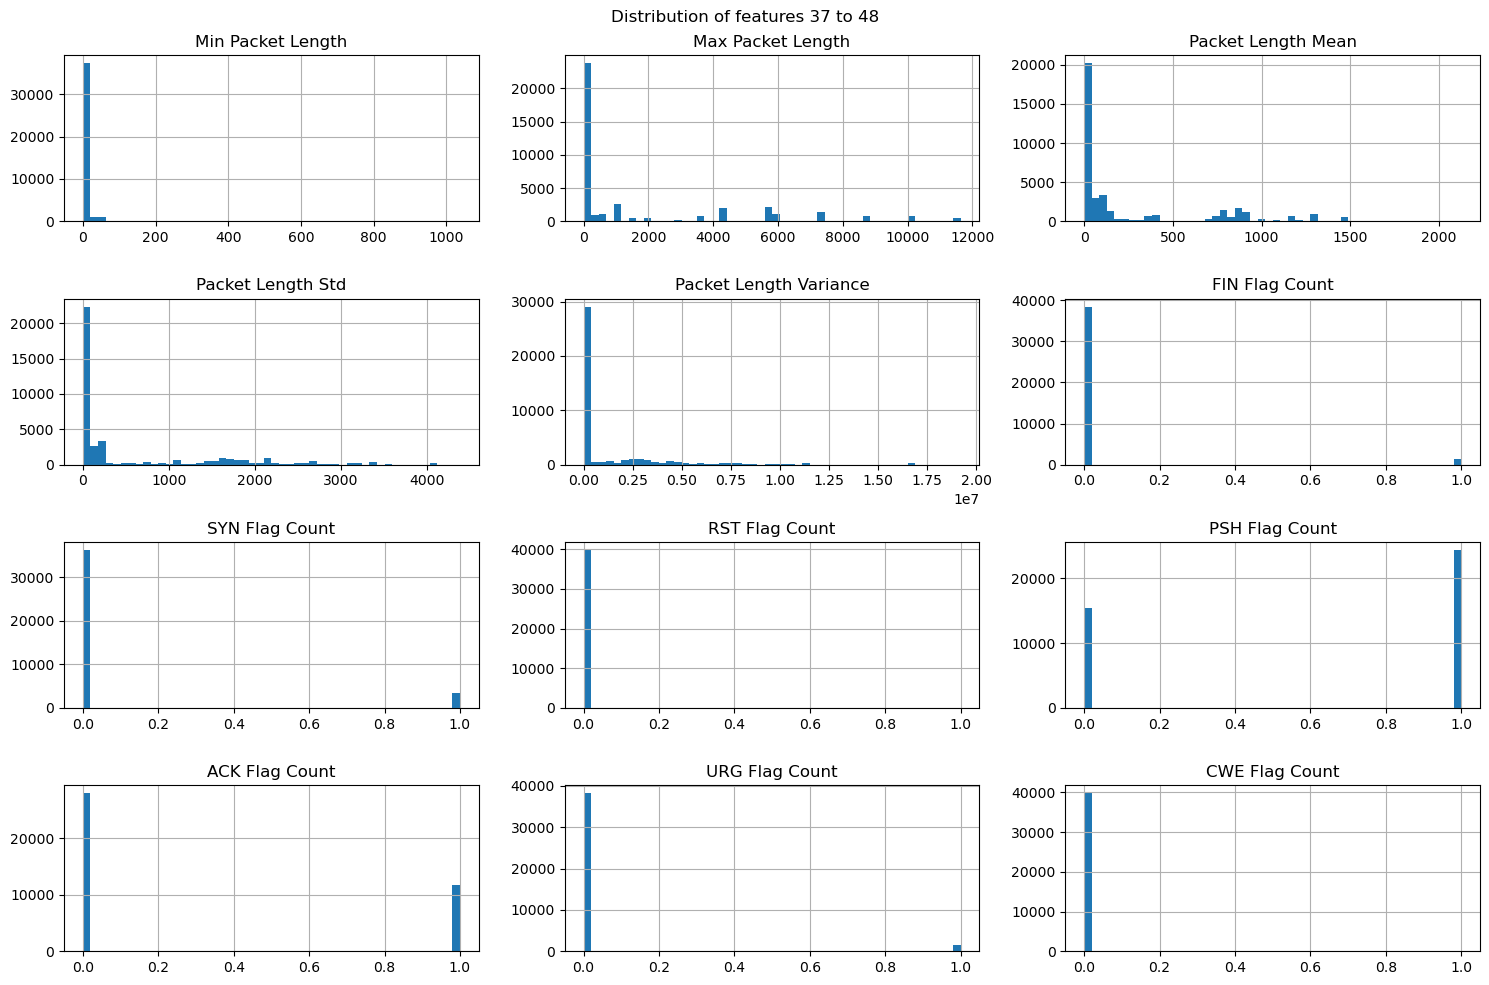

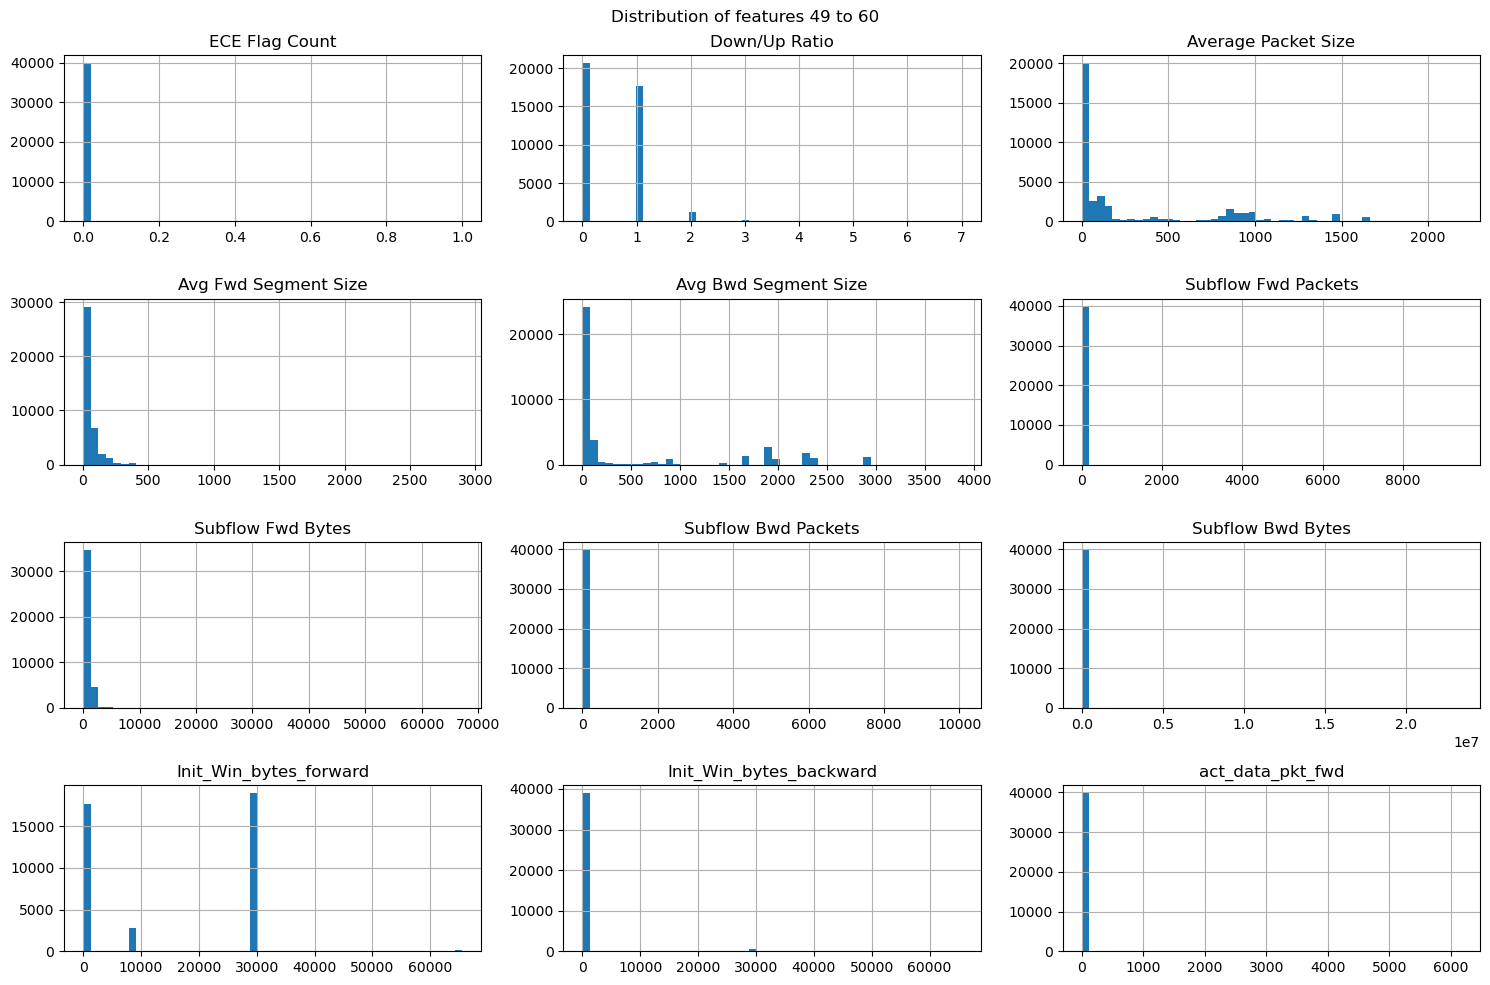

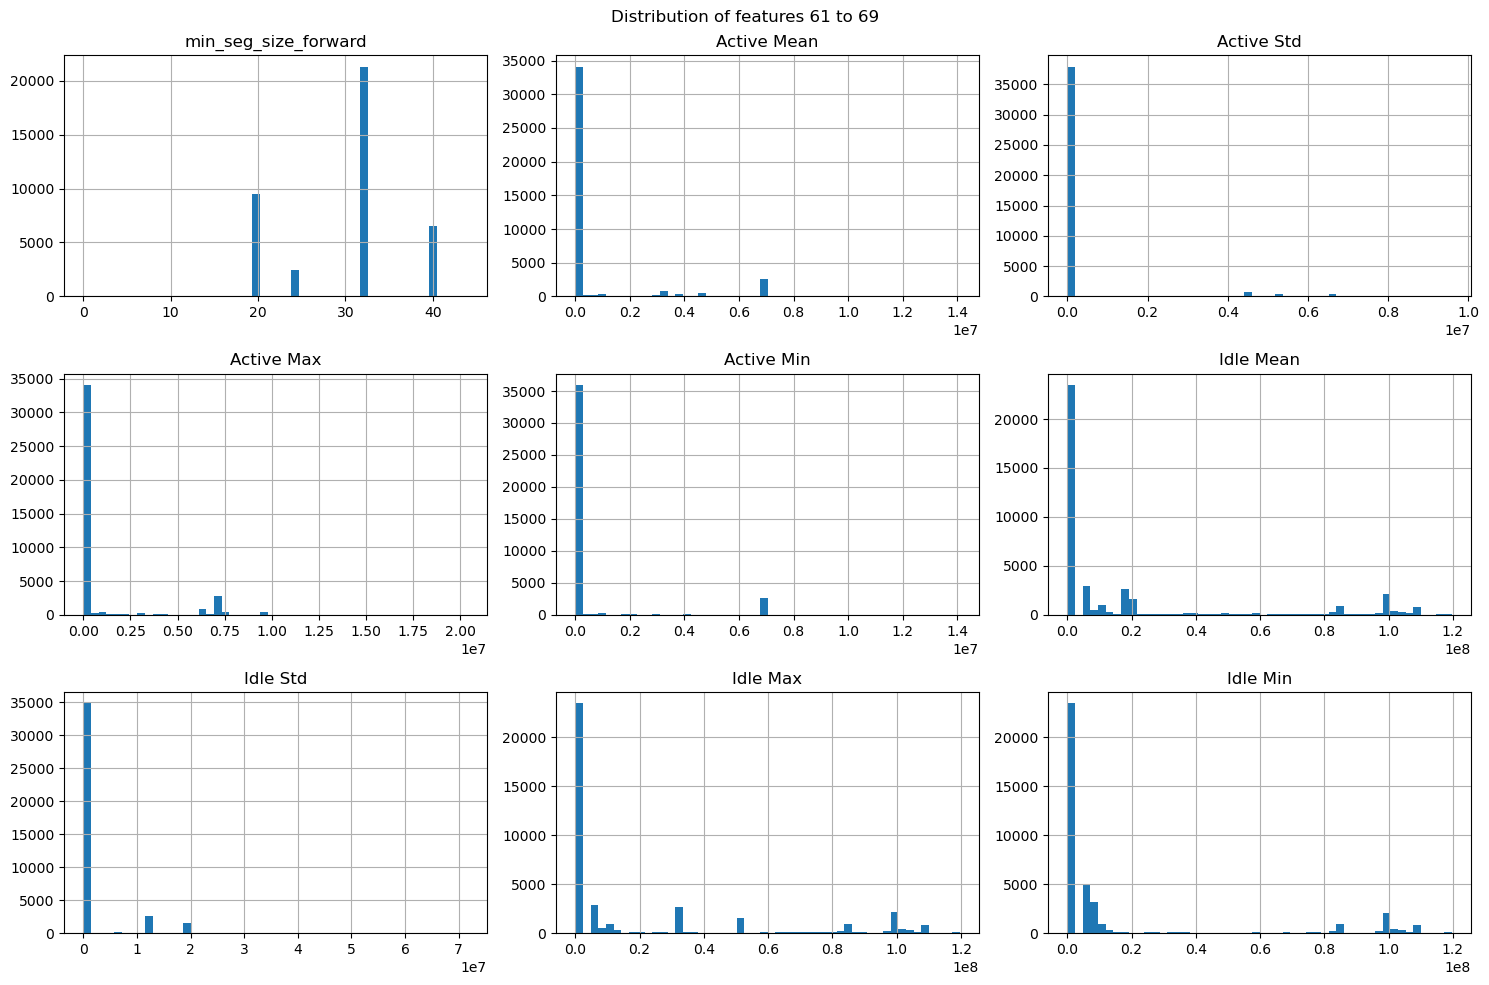

In [26]:
for i in range(0, len(features), 12):

    cols = features[i:i+12]

    df[cols].hist(figsize=(15, 10), bins=50)

    plt.suptitle(f'Distribution of features {i+1} to {i+len(cols)}')
    plt.tight_layout()
    plt.show()

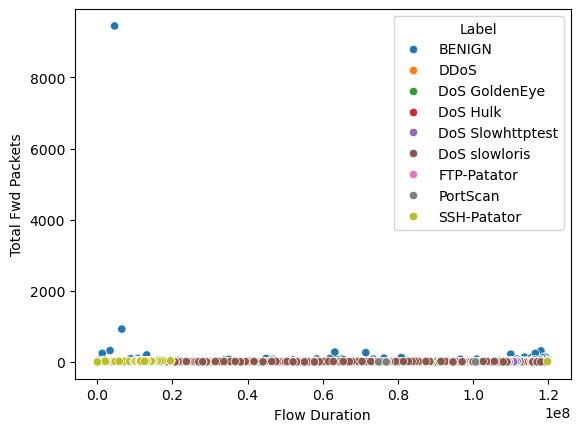

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='Flow Duration',
    y='Total Fwd Packets',
    hue='Label'
)

plt.show()

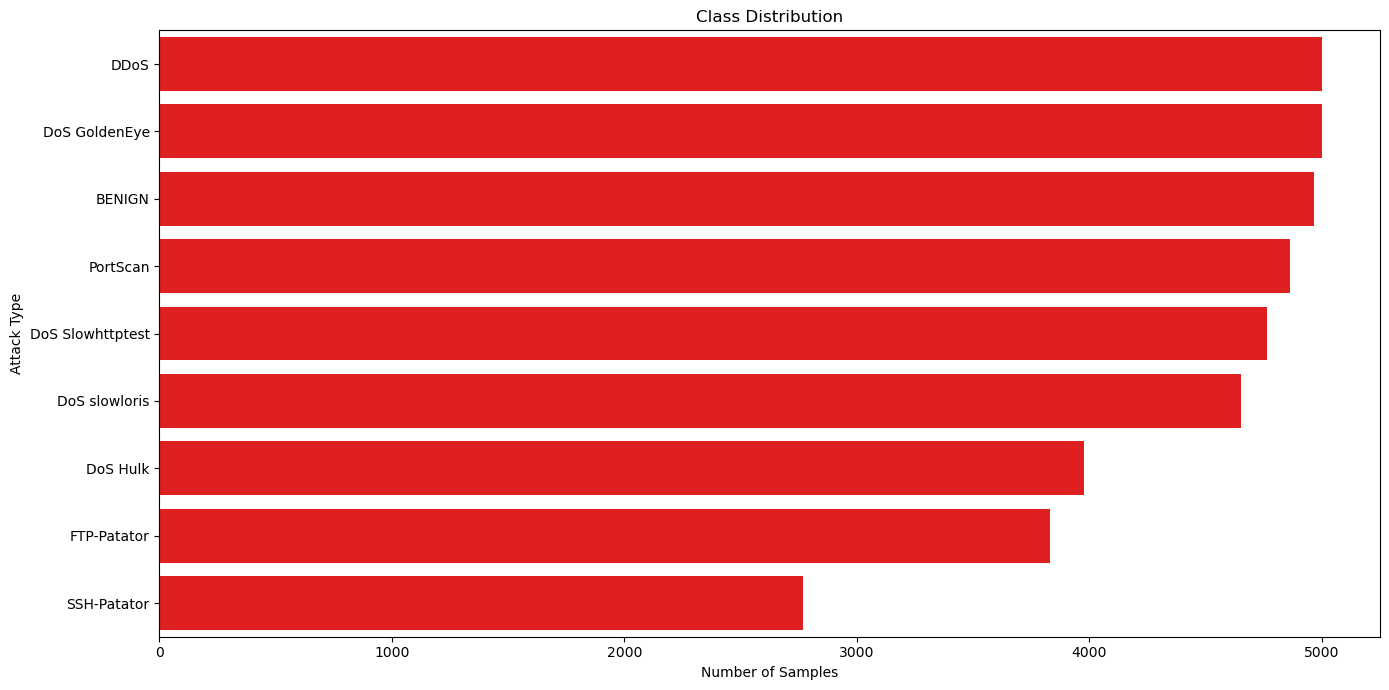

In [28]:
plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    y='Label',
    order=df['Label'].value_counts().index,
    color = 'red'
)

plt.title('Class Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.show()

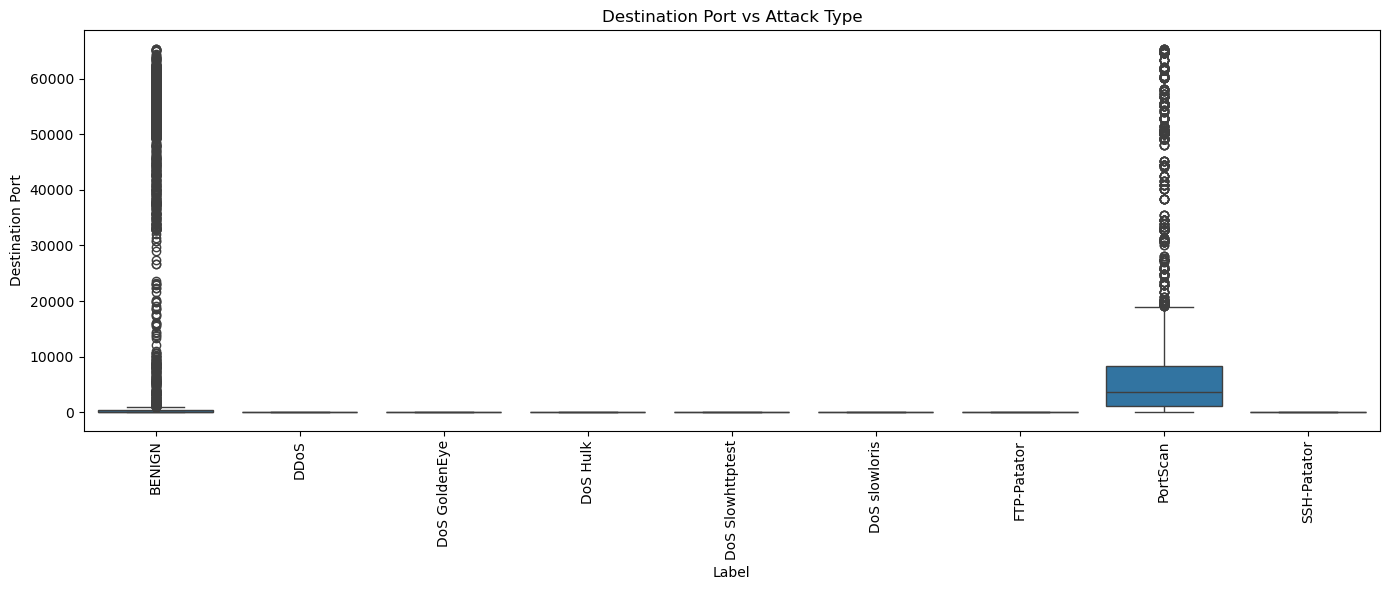

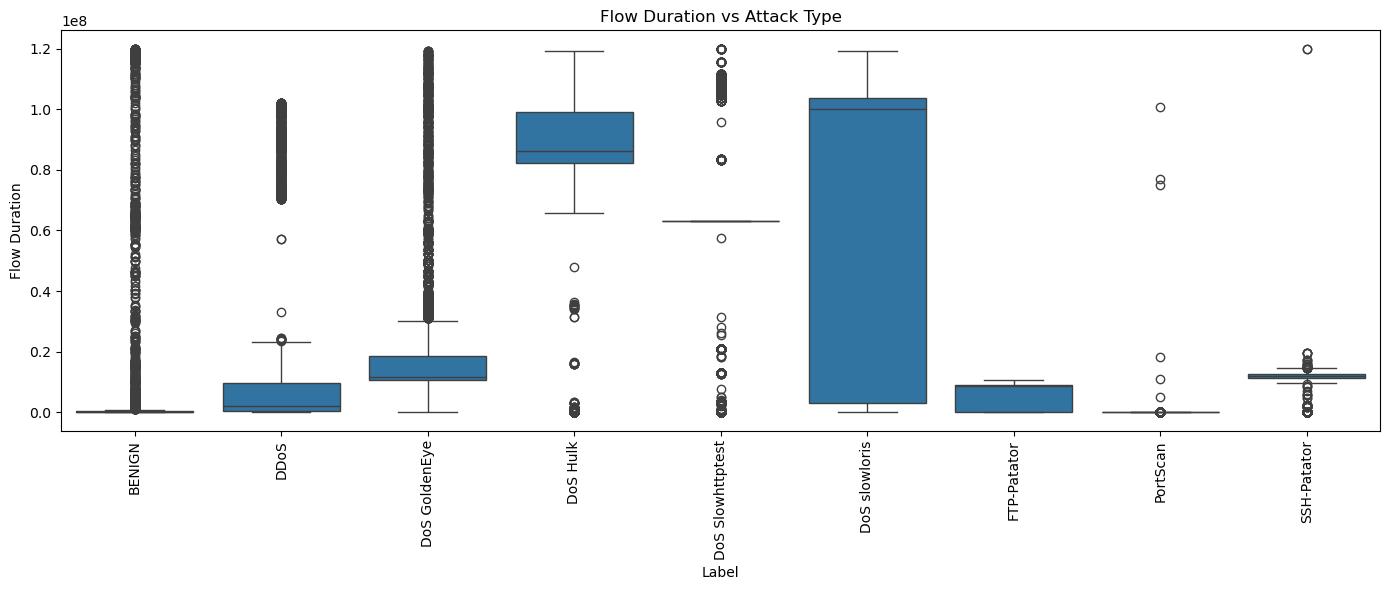

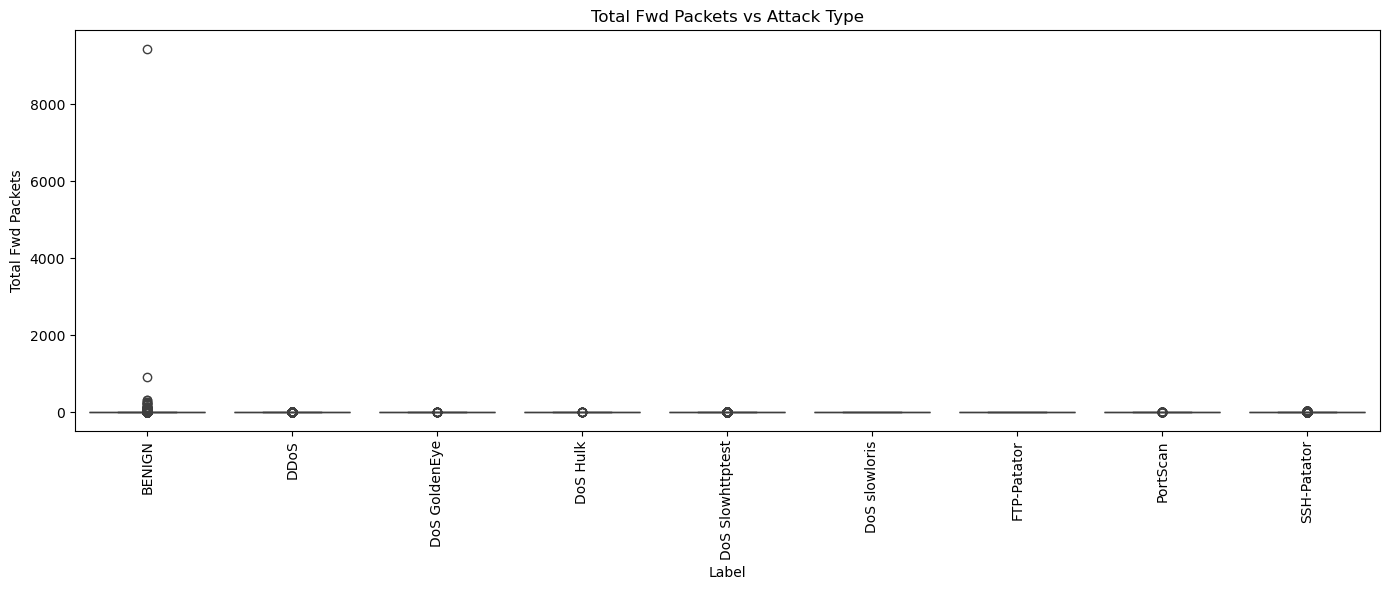

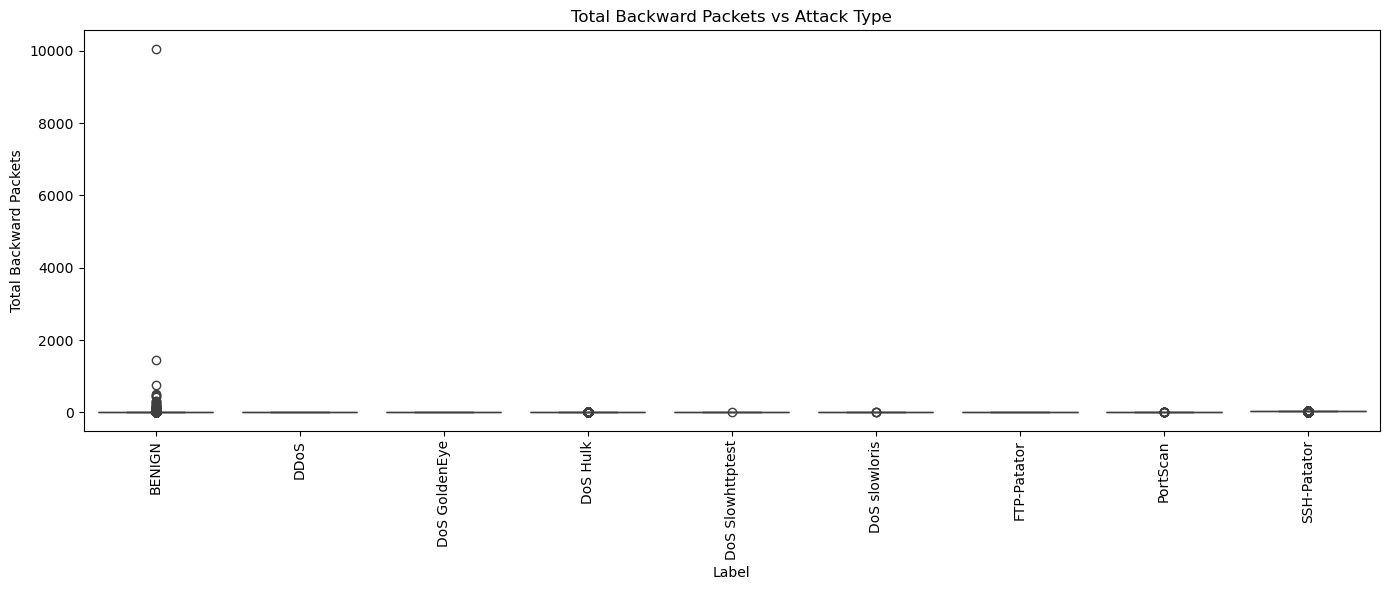

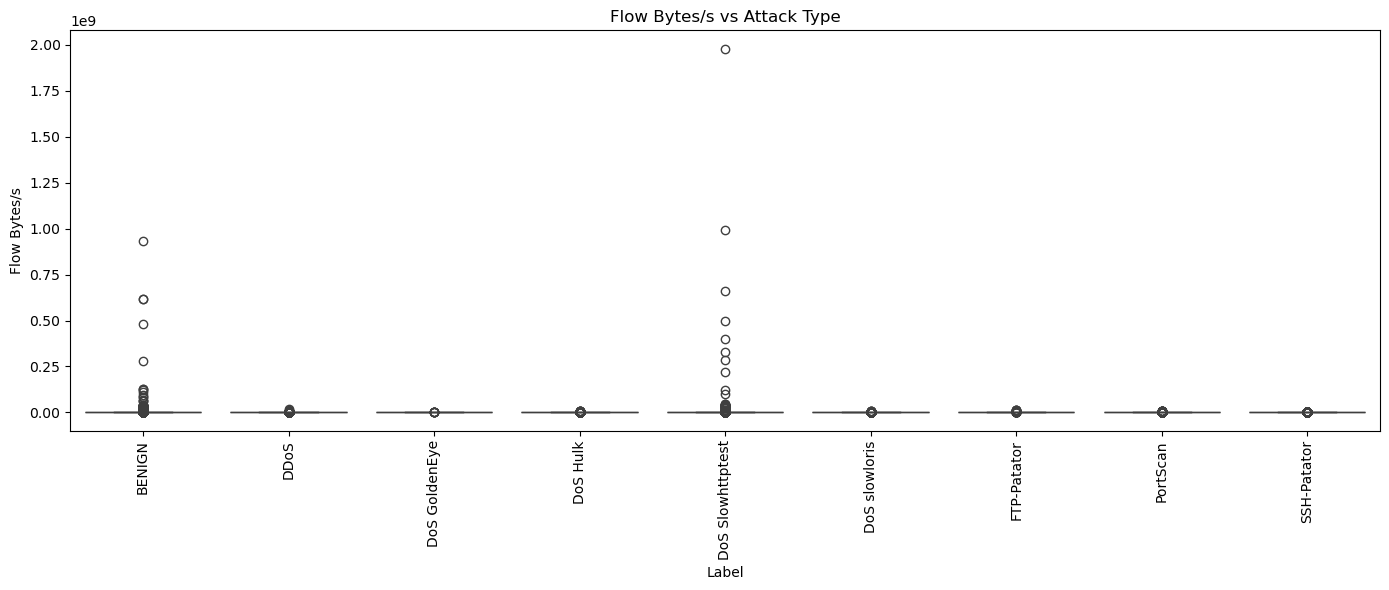

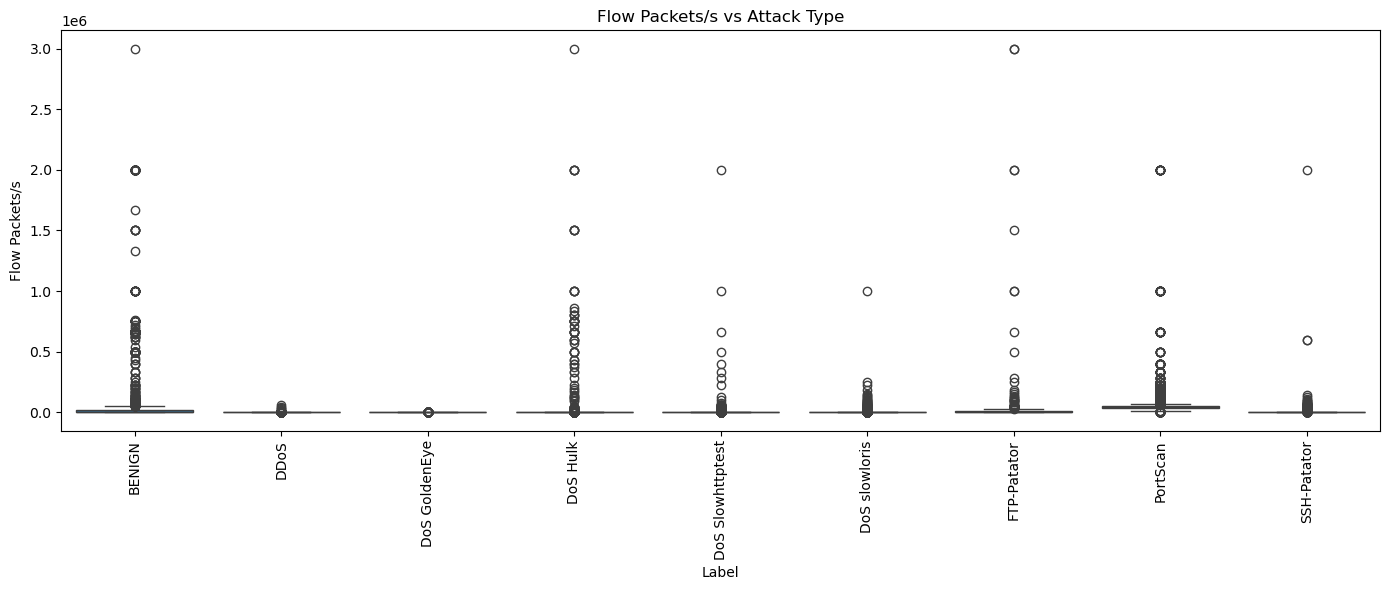

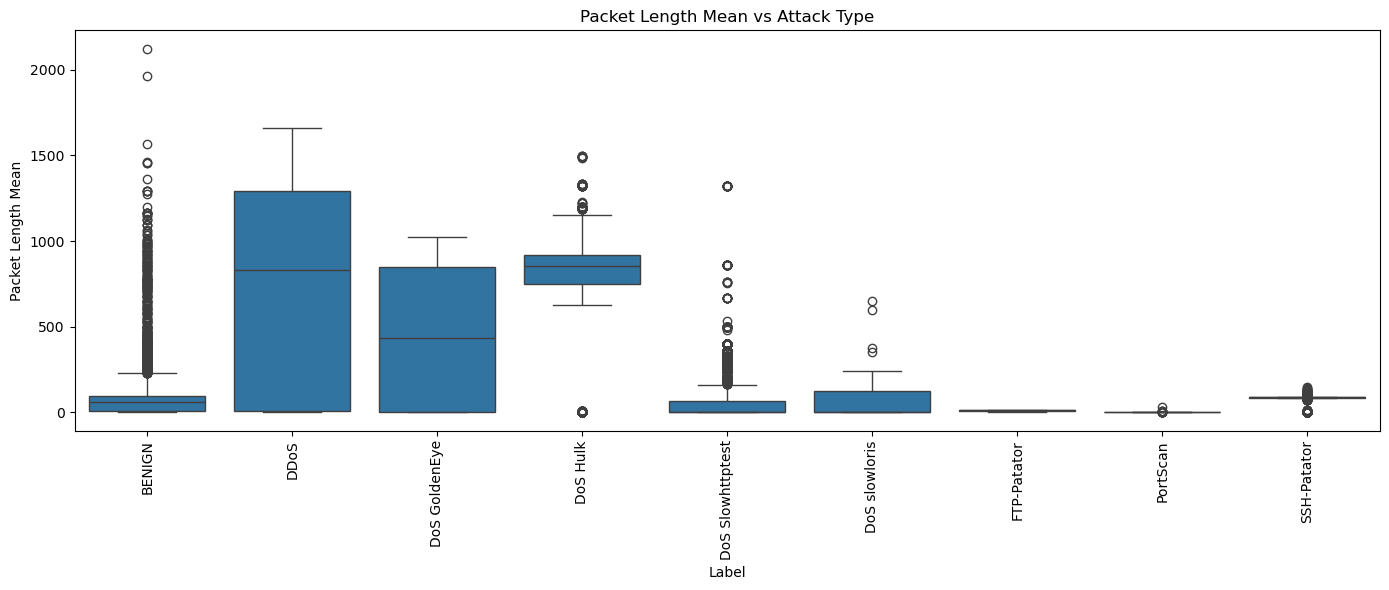

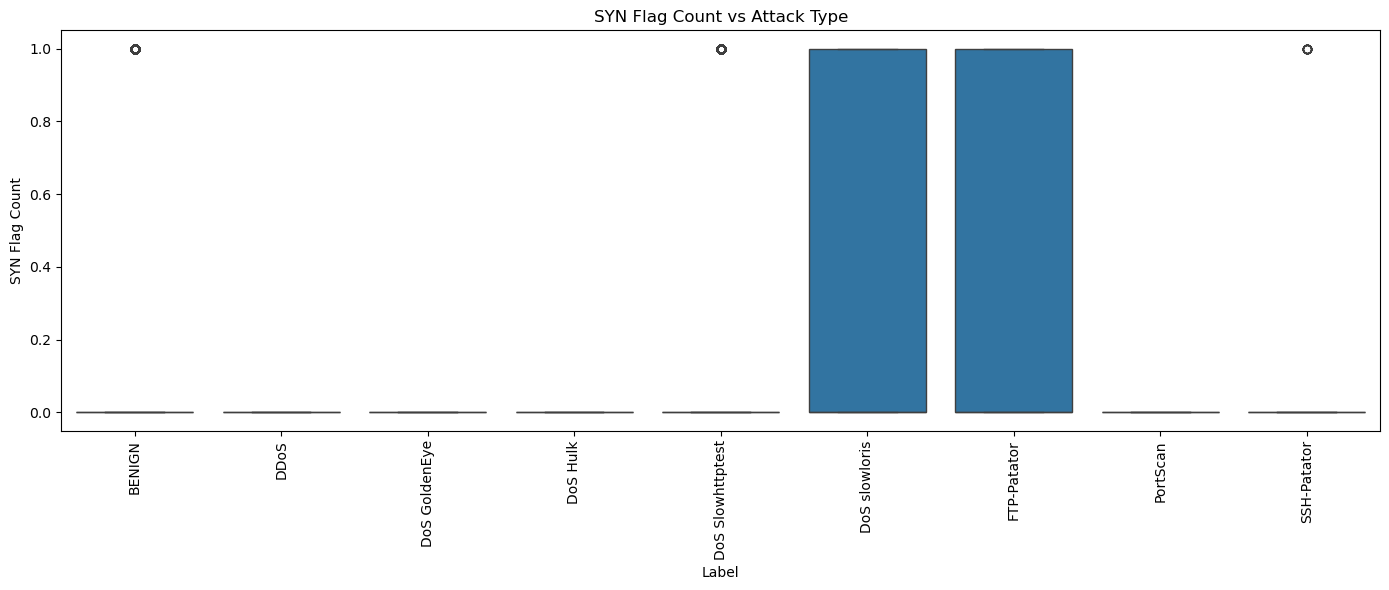

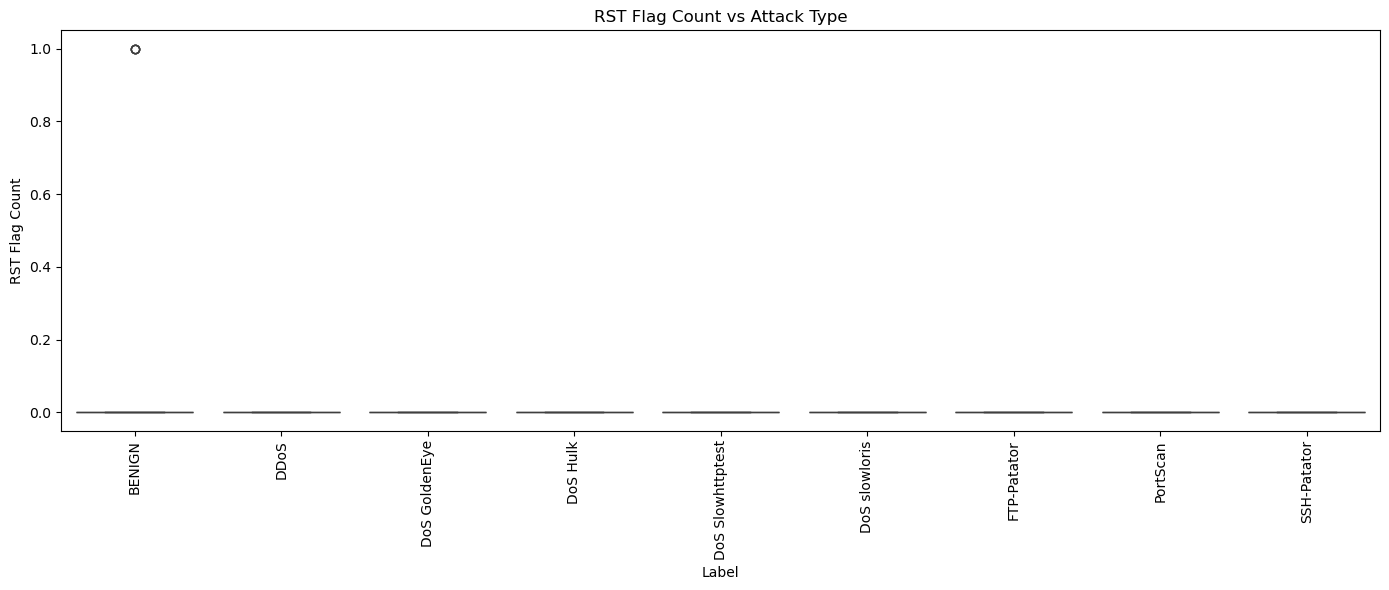

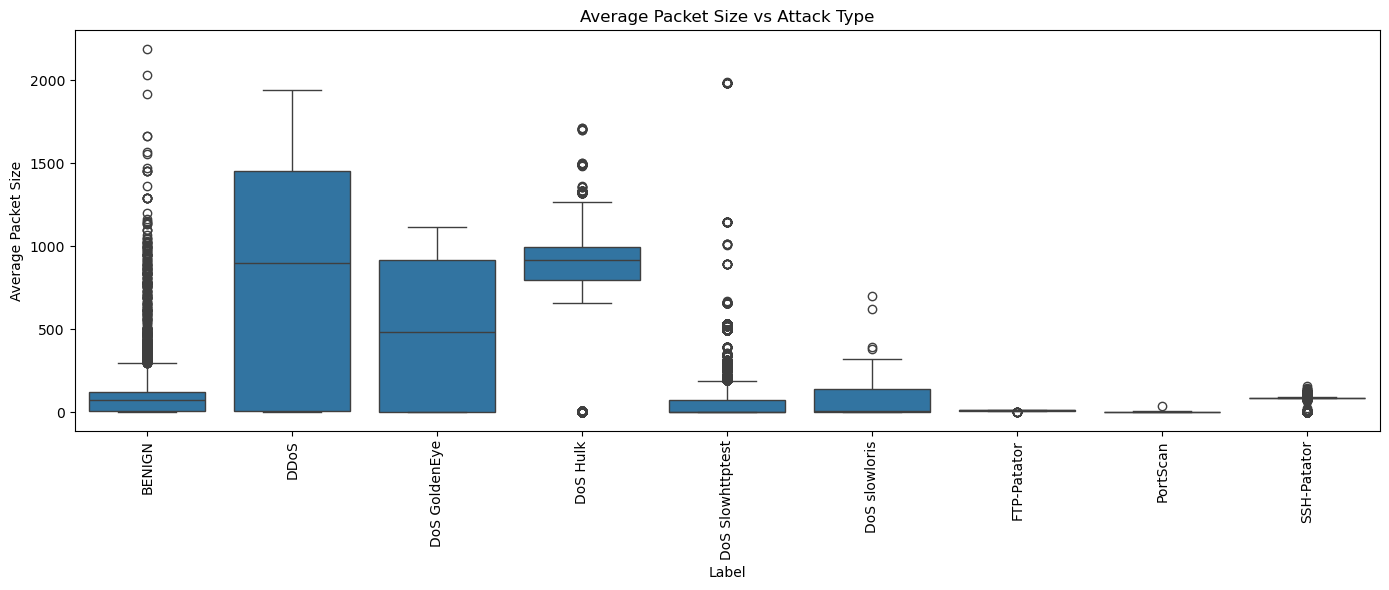

In [29]:
important_features = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'SYN Flag Count',
    'RST Flag Count',
    'Average Packet Size'
]

for feature in important_features:
    plt.figure(figsize=(14, 6))

    sns.boxplot(
        data=df,
        x='Label',
        y=feature
    )

    plt.xticks(rotation=90)
    plt.title(f'{feature} vs Attack Type')
    plt.tight_layout()
    plt.show()

<Axes: xlabel='RST Flag Count'>

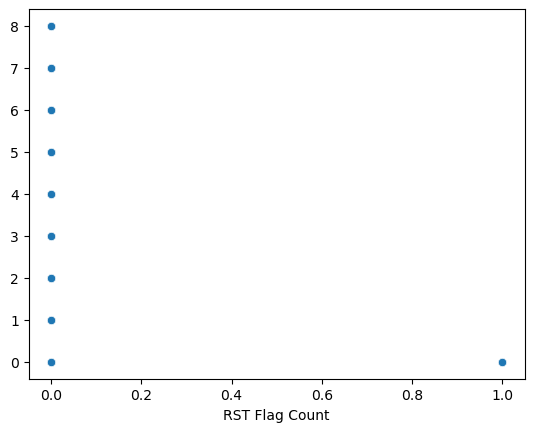

In [30]:
labels, categories = pd.factorize(df['Label'])

sns.scatterplot(data = df, x = 'RST Flag Count', y = labels)

In [31]:
mask = df['RST Flag Count'] > 0
df[mask]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
513,80,60440,5,4,1600,208,1242,0,320.000000,536.272319,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
523,443,3166431,9,8,2456,2550,1032,0,272.888889,434.136915,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2197,443,60529322,12,10,5638,4574,1493,0,469.833333,563.757497,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3067,443,60336870,9,7,1884,4221,821,0,209.333333,311.025321,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [32]:
low_unique = df.nunique().sort_values()

print(low_unique.head(15))

Fwd PSH Flags            2
Fwd URG Flags            2
RST Flag Count           2
SYN Flag Count           2
URG Flag Count           2
ACK Flag Count           2
CWE Flag Count           2
PSH Flag Count           2
ECE Flag Count           2
FIN Flag Count           2
min_seg_size_forward     8
Down/Up Ratio            8
Label                    9
act_data_pkt_fwd        66
Min Packet Length       85
dtype: int64


In [33]:
flag_cols = [
    'Fwd PSH Flags',
    'Fwd URG Flags',
    'RST Flag Count',
    'SYN Flag Count',
    'URG Flag Count',
    'ACK Flag Count',
    'CWE Flag Count',
    'PSH Flag Count',
    'ECE Flag Count',
    'FIN Flag Count'
]

for col in flag_cols:
    print("\n================", col, "================")
    print(pd.crosstab(df[col], df['Label']))


================ Fwd PSH Flags ================
Label          BENIGN  DDoS  DoS GoldenEye  DoS Hulk  DoS Slowhttptest  \
Fwd PSH Flags                                                            
0                4665  5000           4999      3977              4135   
1                 301     0              0         0               628   

Label          DoS slowloris  FTP-Patator  PortScan  SSH-Patator  
Fwd PSH Flags                                                     
0                       3407         2515      4865         2755  
1                       1245         1316         0           12  

================ Fwd URG Flags ================
Label          BENIGN  DDoS  DoS GoldenEye  DoS Hulk  DoS Slowhttptest  \
Fwd URG Flags                                                            
0                4965  5000           4999      3977              4763   
1                   1     0              0         0                 0   

Label          DoS slowloris  FTP-Patato

In [34]:
df = df.drop(columns=[
    'Fwd URG Flags',
    'RST Flag Count',
    'CWE Flag Count',
    'ECE Flag Count'
])

In [35]:
print(df.shape)

(39820, 66)


In [36]:
df.to_csv(data_dir/'clean_data.csv', index = False)